# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

#### **1.1.1**
Load the dataset

In [19]:
# Load the data
df = pd.read_csv(r"C:\Users\Asus\Downloads\Upgrad\C4 Course Project\Advanced_regression_Car_Price\Car_Price_data.csv")
df.head()
df.shape

(15915, 23)

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [22]:
# Find the proportion of missing values in each column and handle if found
# missing values BEFORE fixing
missing_before = df.isnull().sum()
print(missing_before)
print(missing_before.sum())
# Fix missing values
df = df.fillna(df.median(numeric_only=True))   # Numeric columns
df = df.fillna(df.mode().iloc[0])              # Categorical columns
# missing values AFTER fixing
missing_after = df.isnull().sum()
print(missing_after)
print(missing_after.sum())

make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type             0
Upholstery_type        0
Gearing_Type           0
Displacement_cc        0
Weight_kg              0
Drive_chain            0
cons_comb              0
dtype: int64
0
make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

Numerical predictors: ['km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']


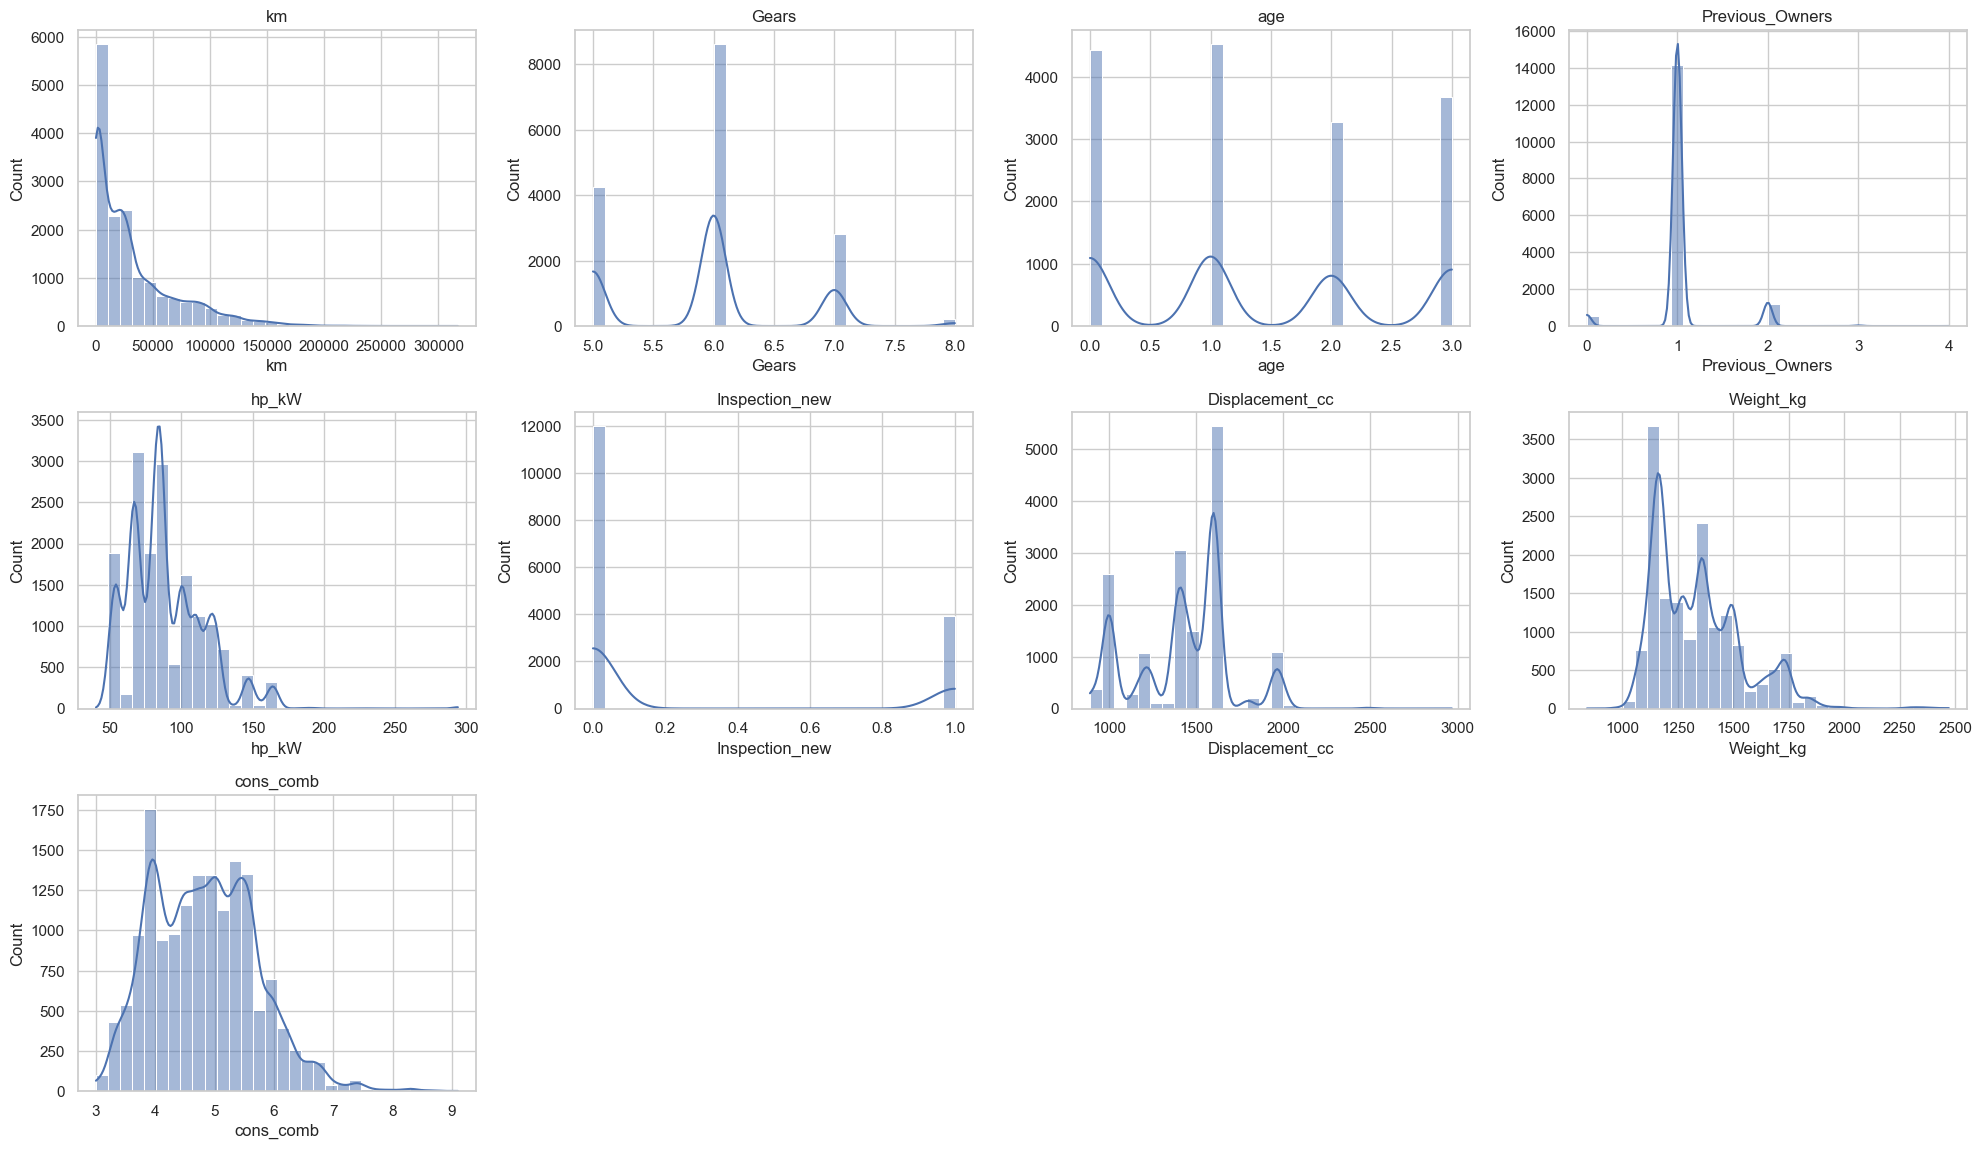

In [23]:
# Identify numerical features and plot histograms
import matplotlib.pyplot as plt
import seaborn as sns
#target variable
target = 'price'
# numerical predictors (exclude target)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove(target)   # remove target from predictors
print("Numerical predictors:",numerical_features)
# histograms for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

Categorical predictors: ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']


C:\Users\Asus\AppData\Local\Temp\ipykernel_1744\624861031.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


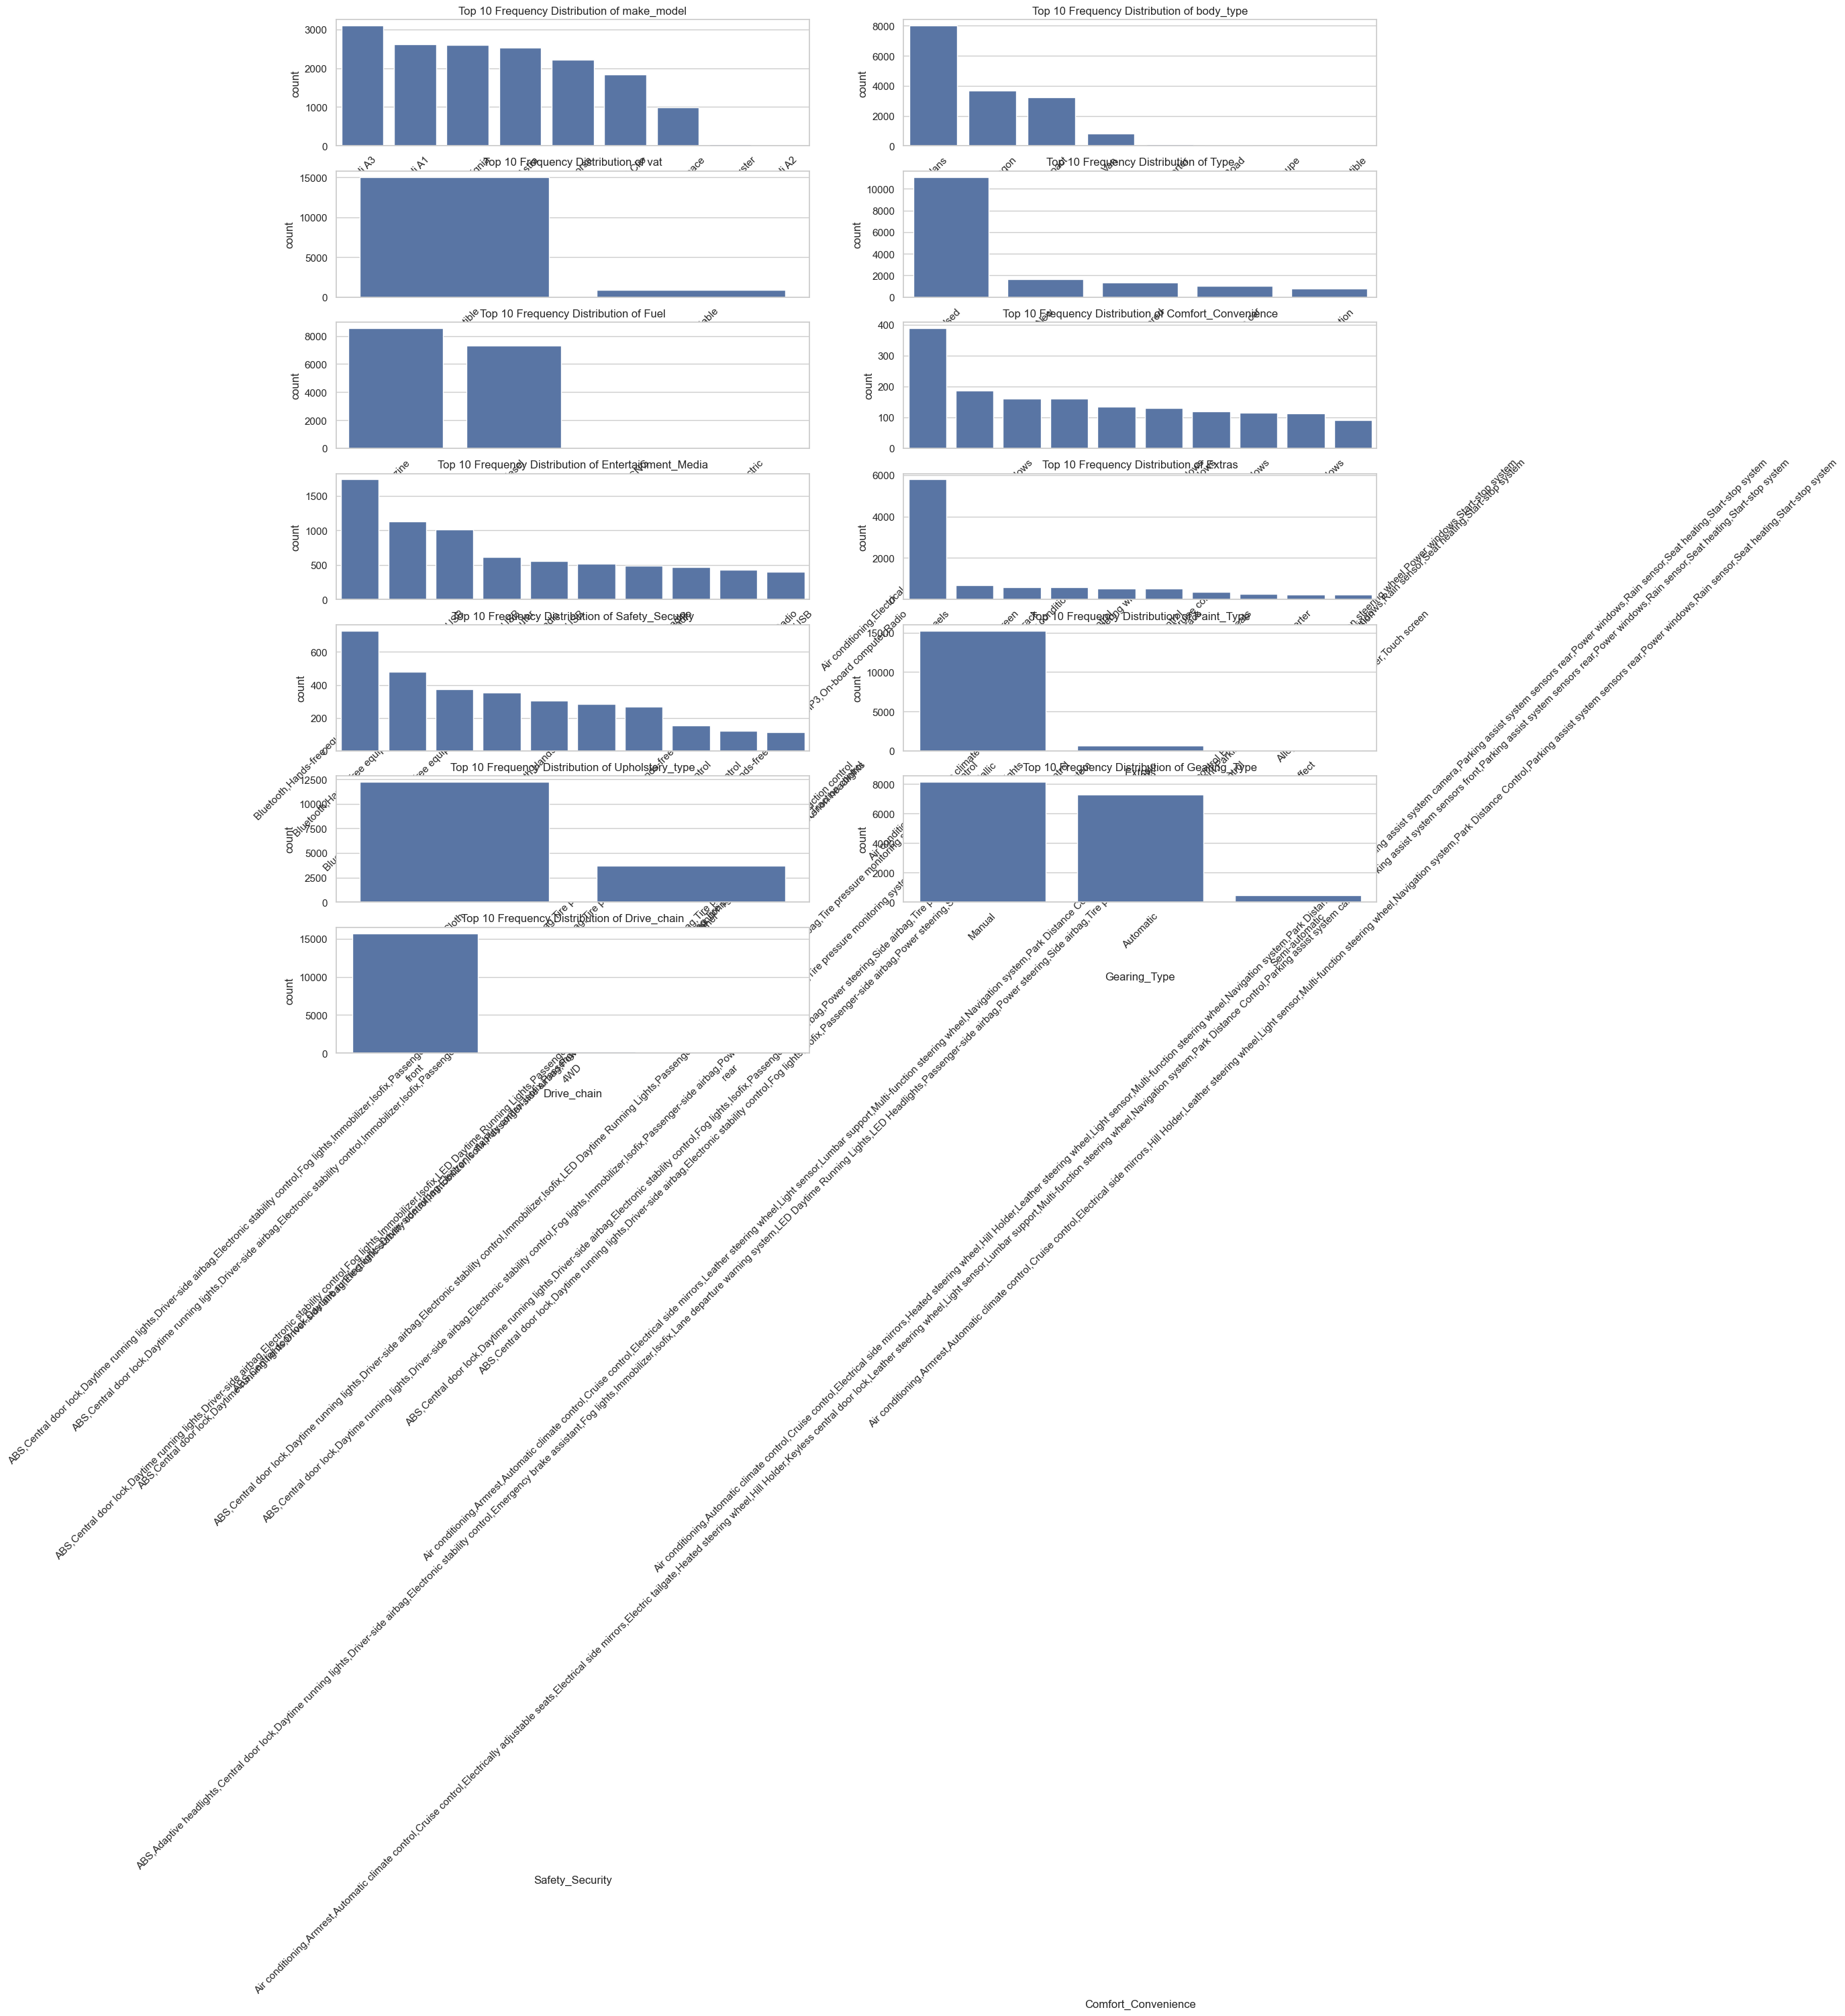

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical predictors:", categorical_features)

# Plot frequency distributions (top 10 categories)
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_features):
    plt.subplot(len(categorical_features)//2 + 1, 2, i+1)
    
    # Get top 10 categories
    top_categories = df[col].value_counts().nlargest(10).index
    
    sns.countplot(data=df[df[col].isin(top_categories)], x=col, order=top_categories)
    plt.xticks(rotation=45)
    plt.title(f'Top 10 Frequency Distribution of {col}')
    
plt.tight_layout()
plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [29]:
# Fix columns as needed
# Handle Type column - group rare categories
df['Type'] = df['Type'].replace({
    'Pre-registered': 'New/Other',
    "Employee's car": 'New/Other',
    'Demonstration': 'New/Other'
})

# Check frequency counts for all categorical columns
for col in categorical_features:
    freq = df[col].value_counts(normalize=True)
    rare_categories = freq[freq < 0.01].index  # less than 1%
    df[col] = df[col].replace(rare_categories, 'Other')

# count features in bundled columns
bundled_cols = ["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]
for col in bundled_cols:
    df[col + '_count'] = df[col].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Verification
df[categorical_features + [c + '_count' for c in bundled_cols]].head()


,make_model,body_type,vat,Type,Fuel,Comfort_Convenience,Entertainment_Media,Extras,Safety_Security,Paint_Type,Upholstery_type,Gearing_Type,Drive_chain,Comfort_Convenience_count,Entertainment_Media_count,Extras_count,Safety_Security_count
0,Audi A1,Sedans,VAT deductible,Used,Diesel,Other,"Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Catalytic Converter,Voice Control","ABS,Central door lock,Daytime running lights,D...",Metallic,Cloth,Automatic,front,1,4,3,14
1,Audi A1,Sedans,Price negotiable,Used,Benzine,Other,Other,Other,Other,Metallic,Cloth,Automatic,front,1,1,1,1
2,Audi A1,Sedans,VAT deductible,Used,Diesel,Other,Other,"Alloy wheels,Voice Control","ABS,Central door lock,Daytime running lights,D...",Metallic,Cloth,Automatic,front,1,1,2,12
3,Audi A1,Sedans,VAT deductible,Used,Diesel,Other,"Bluetooth,CD player,Hands-free equipment,MP3,O...","Alloy wheels,Sport seats,Voice Control",Other,Metallic,Cloth,Automatic,front,1,8,3,1
4,Audi A1,Sedans,VAT deductible,Used,Diesel,Other,"Bluetooth,CD player,Hands-free equipment,MP3,O...",Other,Other,Metallic,Cloth,Automatic,front,1,7,1,1


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

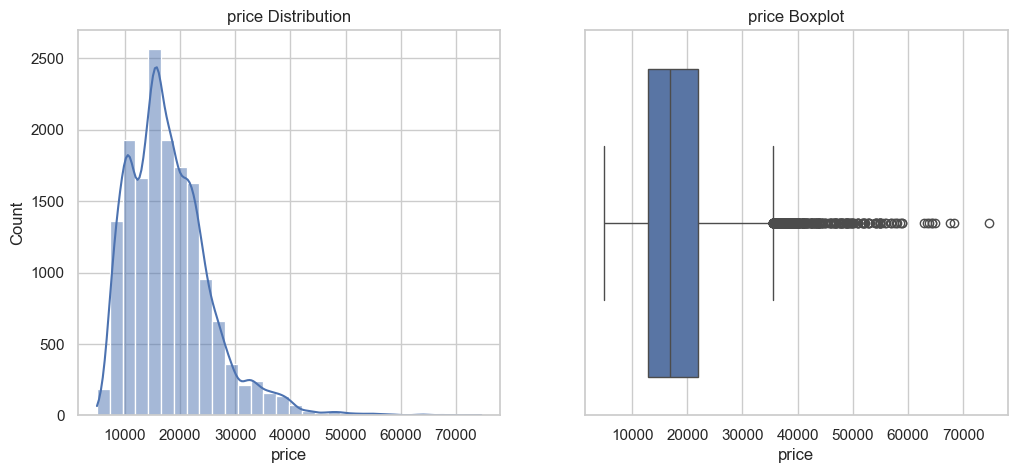

Skewness of price: 1.24


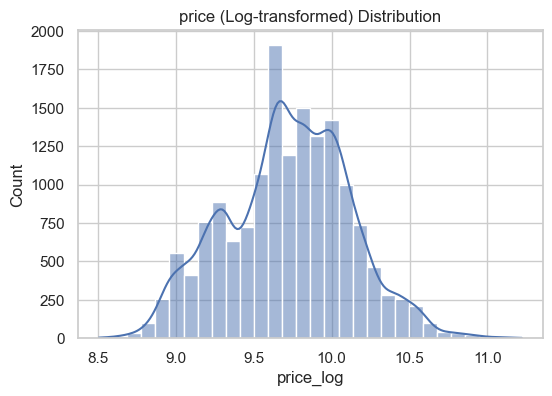

In [32]:
# Plot histograms for target feature
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target = 'price'
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[target], bins=30, kde=True)
plt.title(f'{target} Distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df[target])
plt.title(f'{target} Boxplot')

plt.show()

# Check skewness
skewness = df[target].skew()
print(f"Skewness of {target}: {skewness:.2f}")

# Apply log transformation if highly skewed
if abs(skewness) > 1:
    df[target + '_log'] = np.log1p(df[target])  # log(1+x) to handle zeros
    plt.figure(figsize=(6,4))
    sns.histplot(df[target + '_log'], bins=30, kde=True)
    plt.title(f'{target} (Log-transformed) Distribution')
    plt.show()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

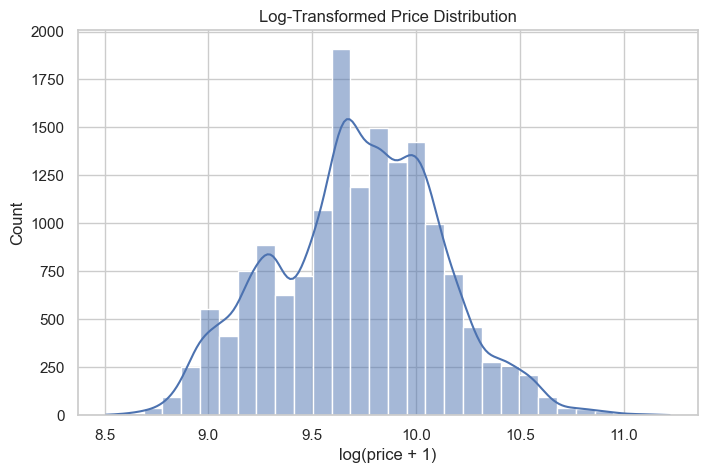

In [33]:
# Transform the target feature
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['price_log'] = np.log1p(df['price'])
plt.figure(figsize=(8,5))
sns.histplot(df['price_log'], bins=30, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.xlabel('log(price + 1)')
plt.show()

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

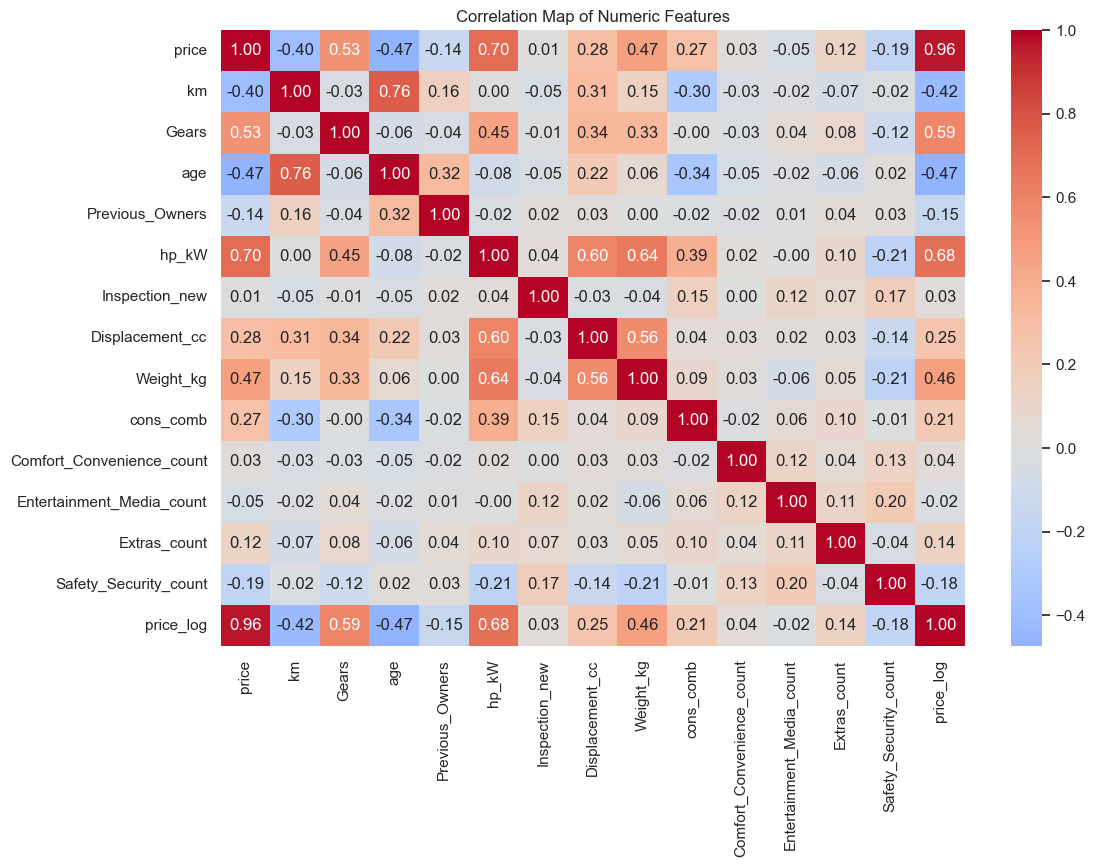

In [35]:
# Visualise correlation
import matplotlib.pyplot as plt
import seaborn as sns

# numeric features for correlation
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# correlation matrix
corr_matrix = df[numeric_features].corr()

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Map of Numeric Features')
plt.show()

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

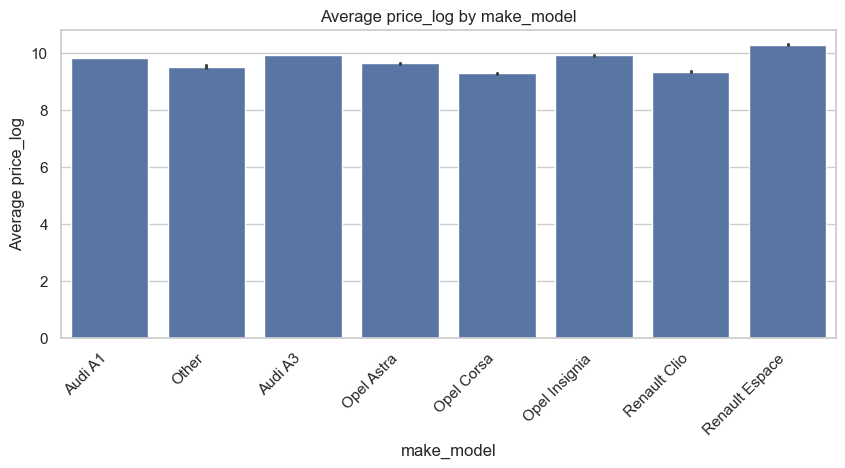

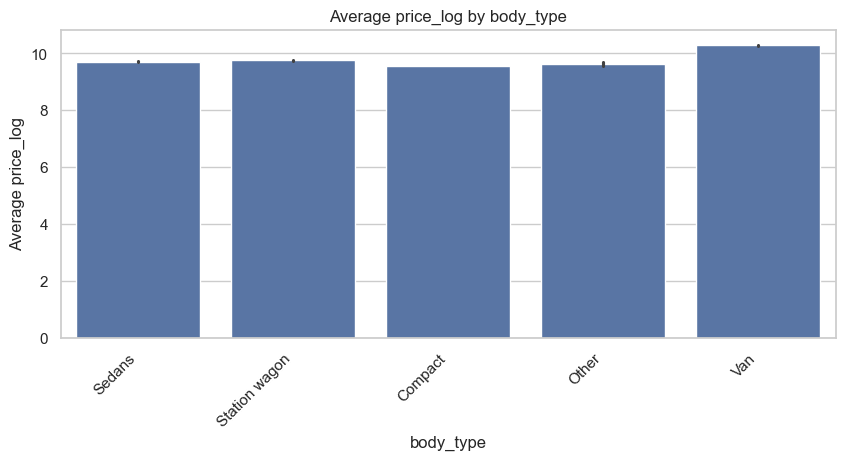

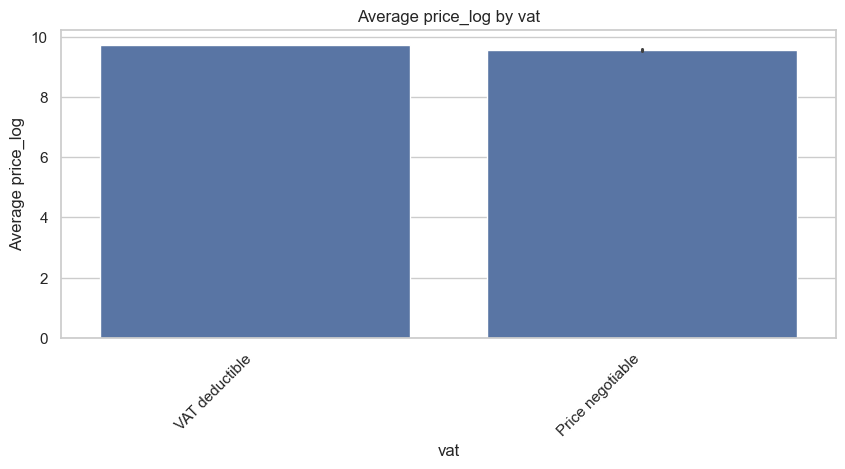

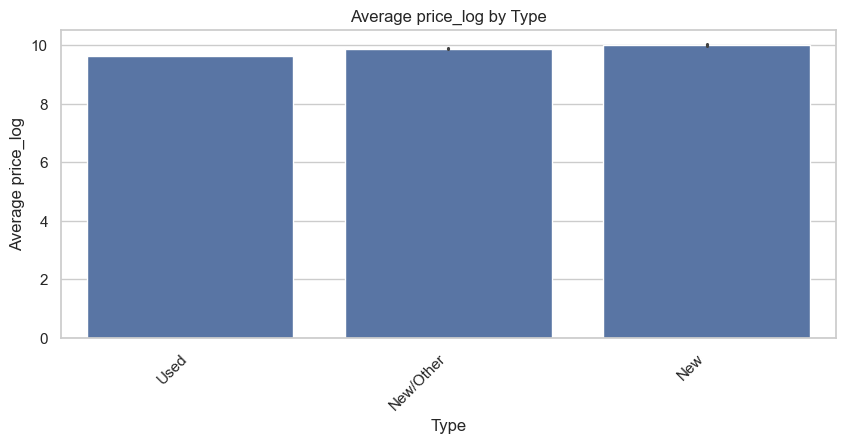

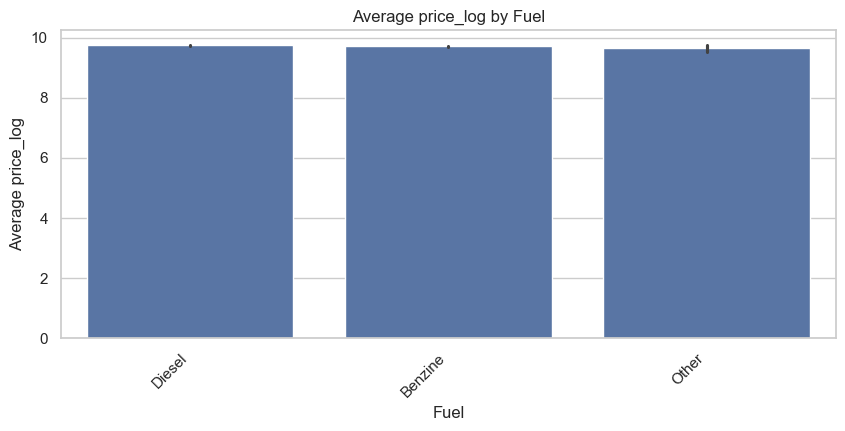

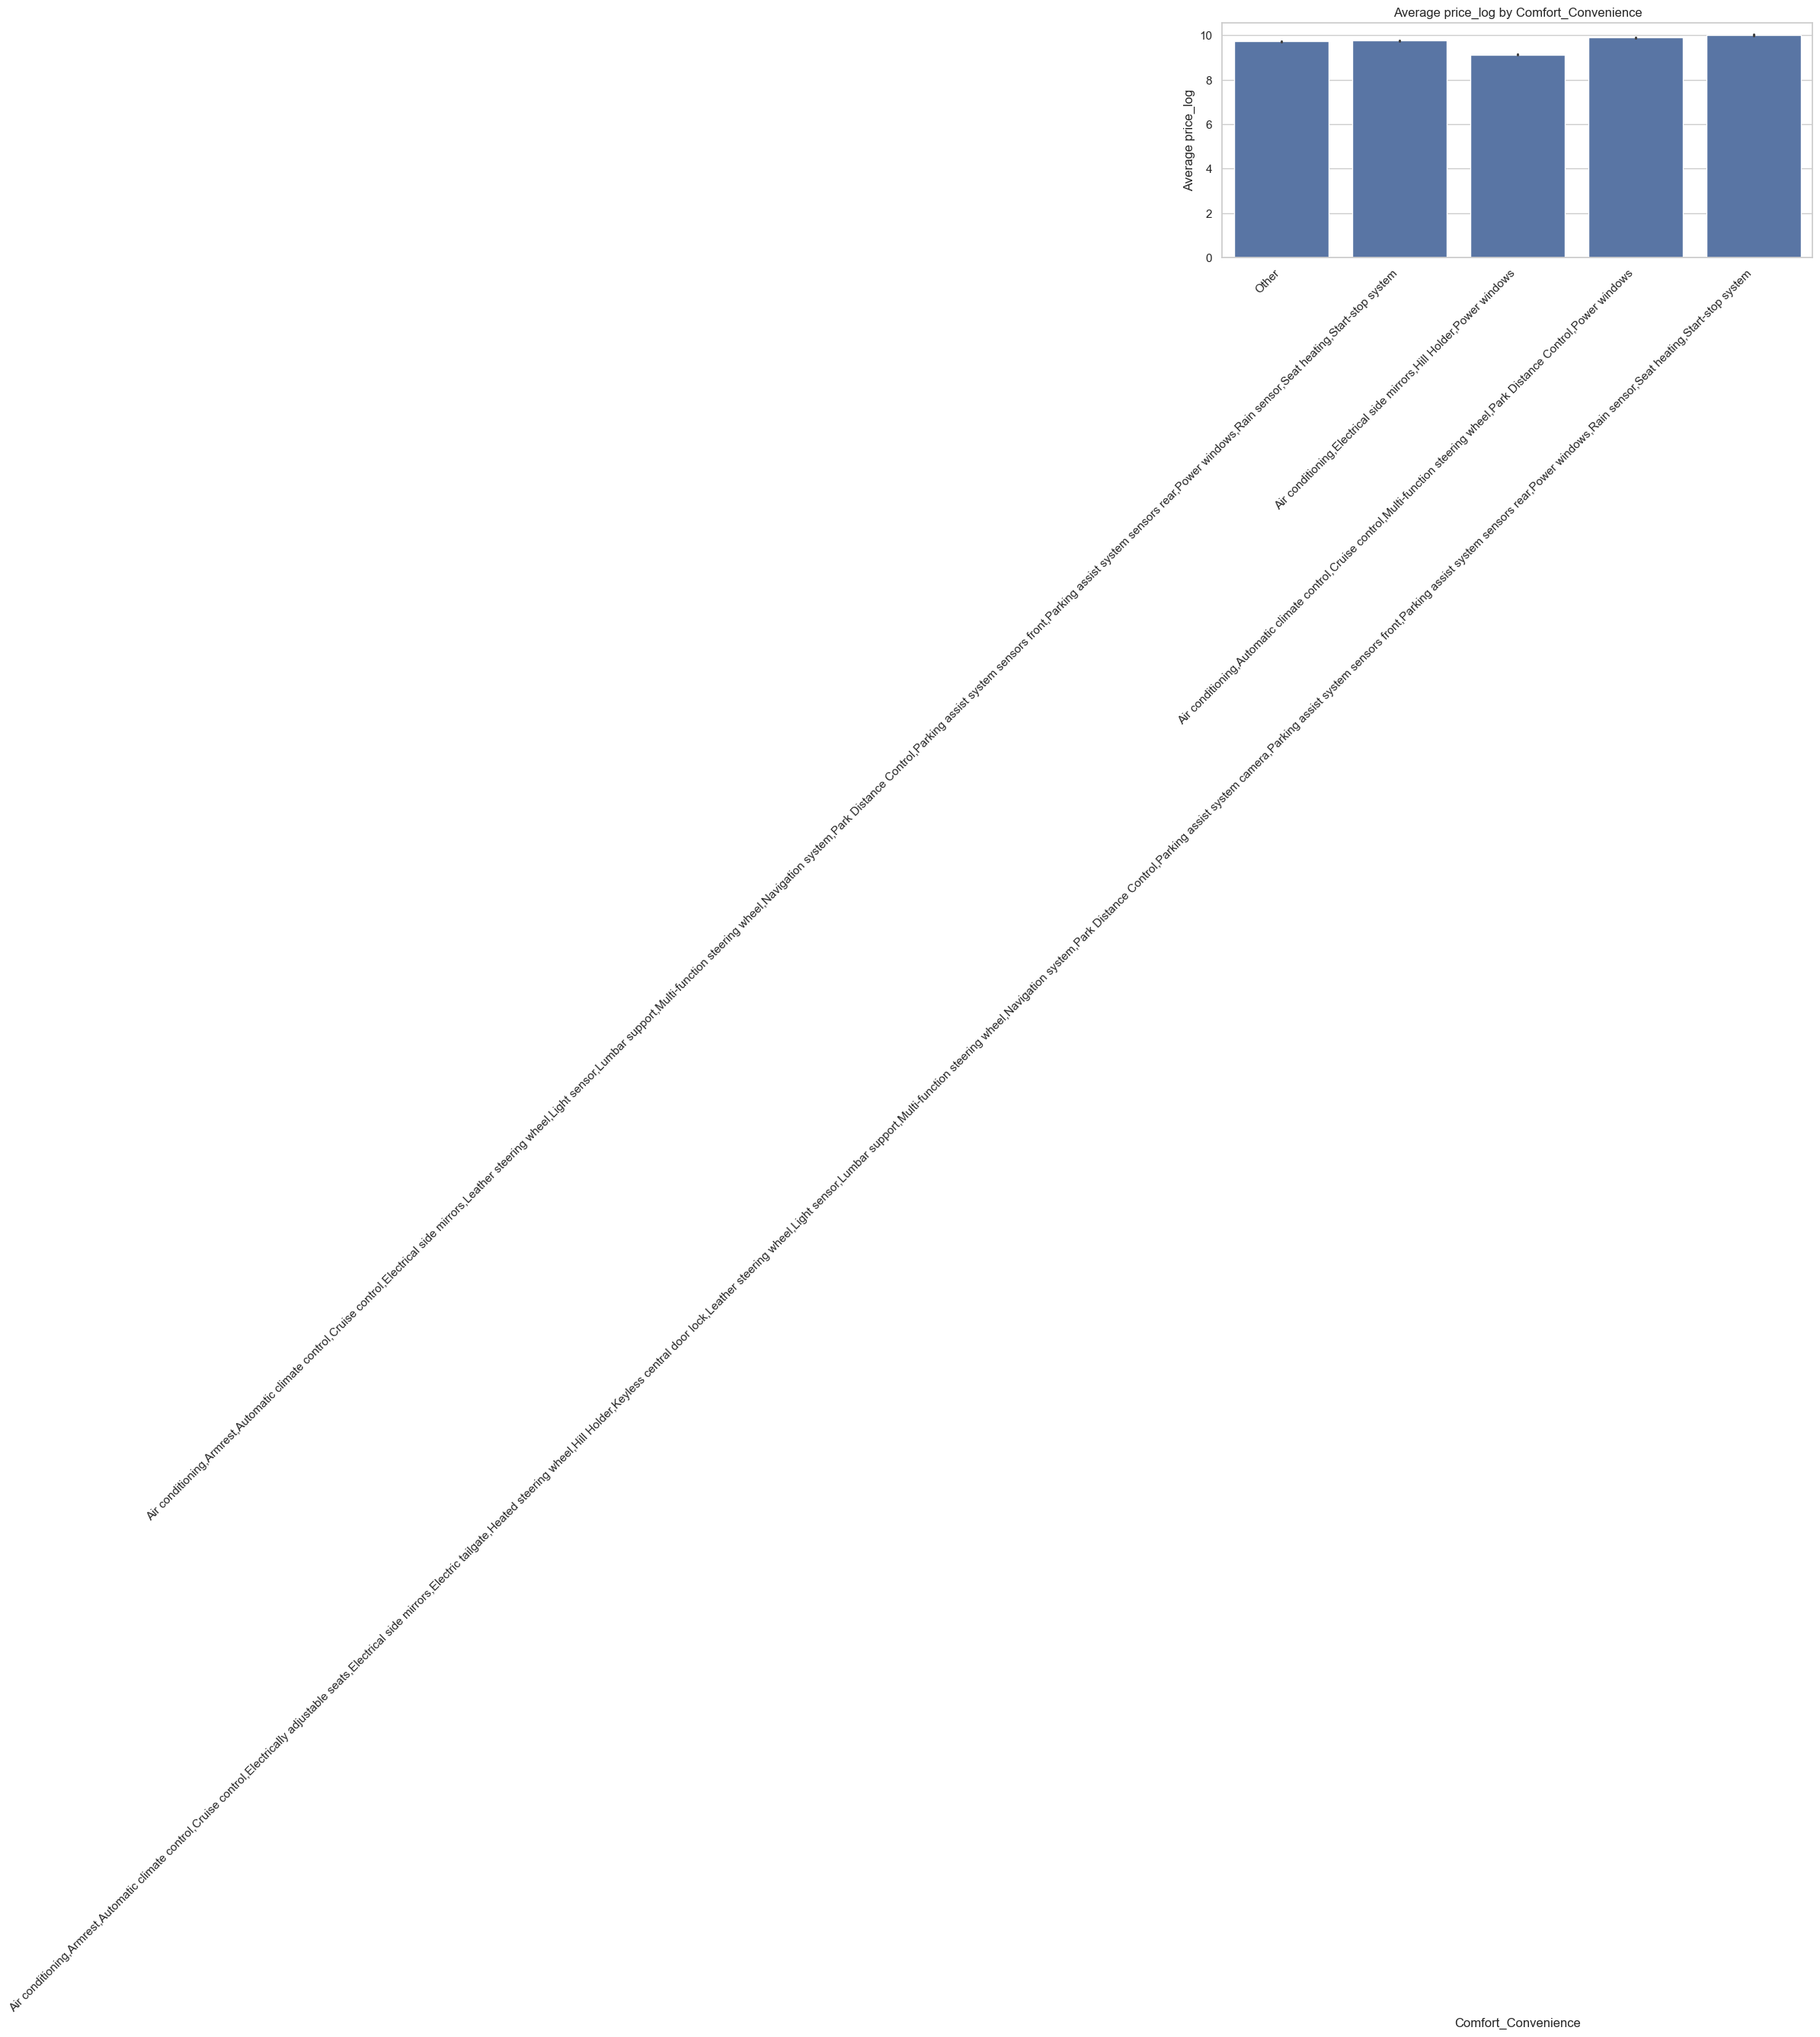

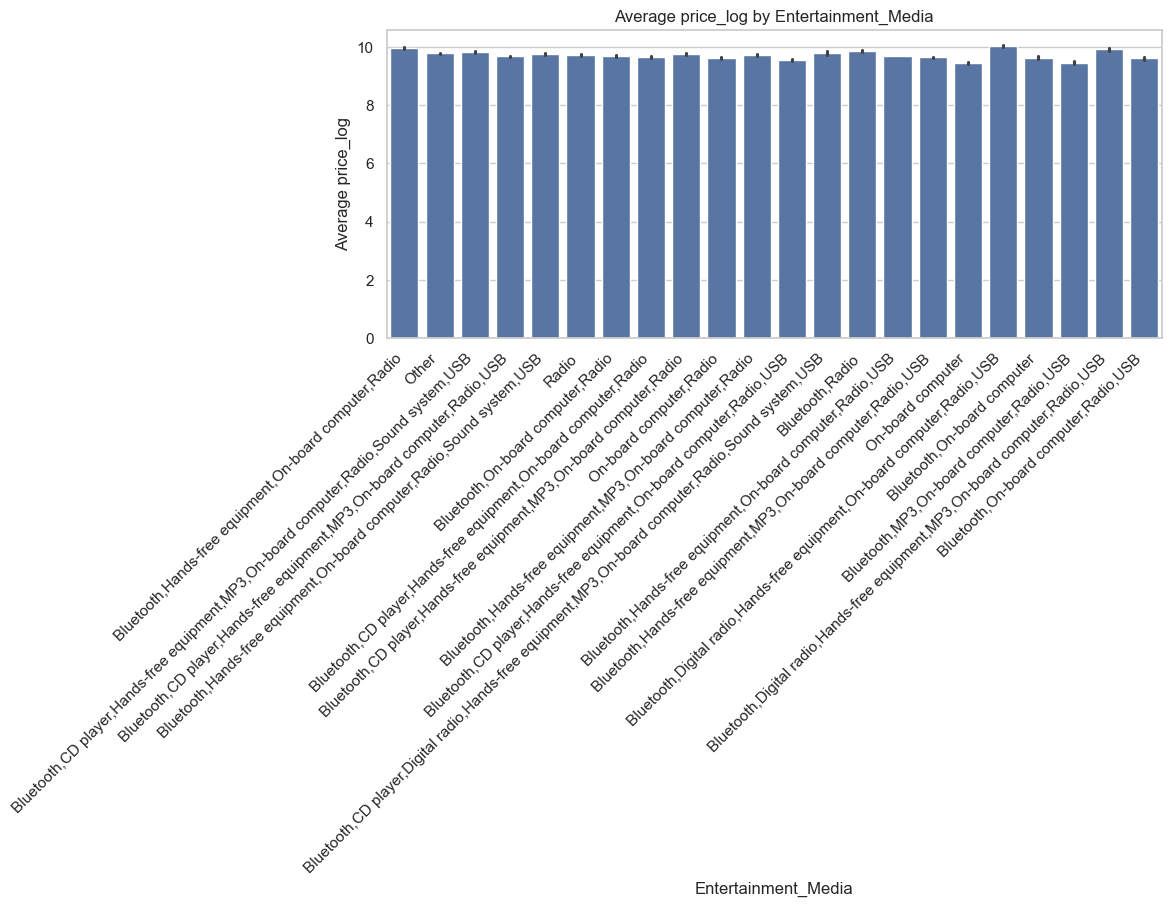

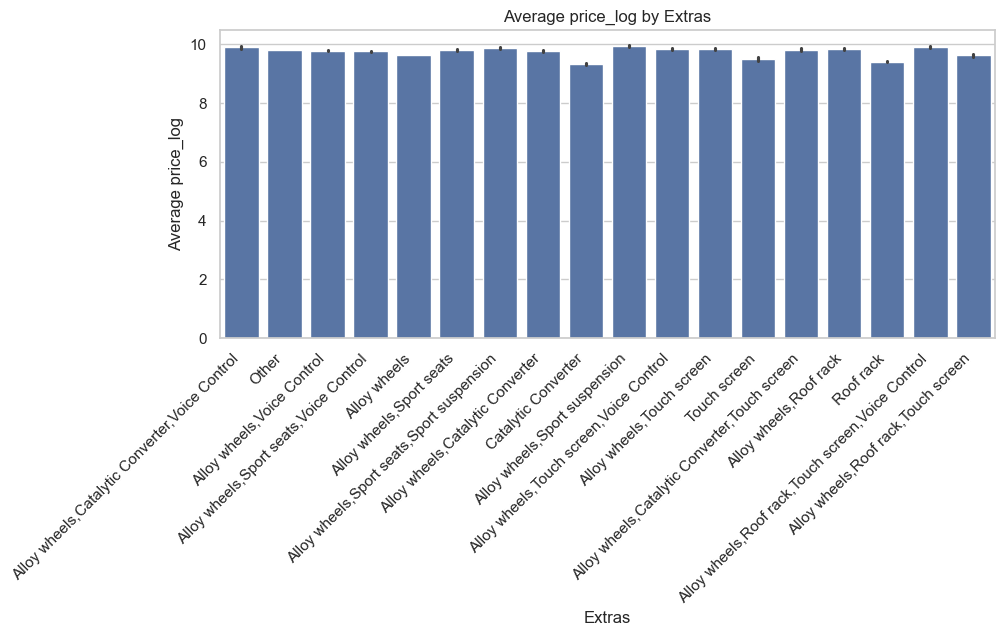

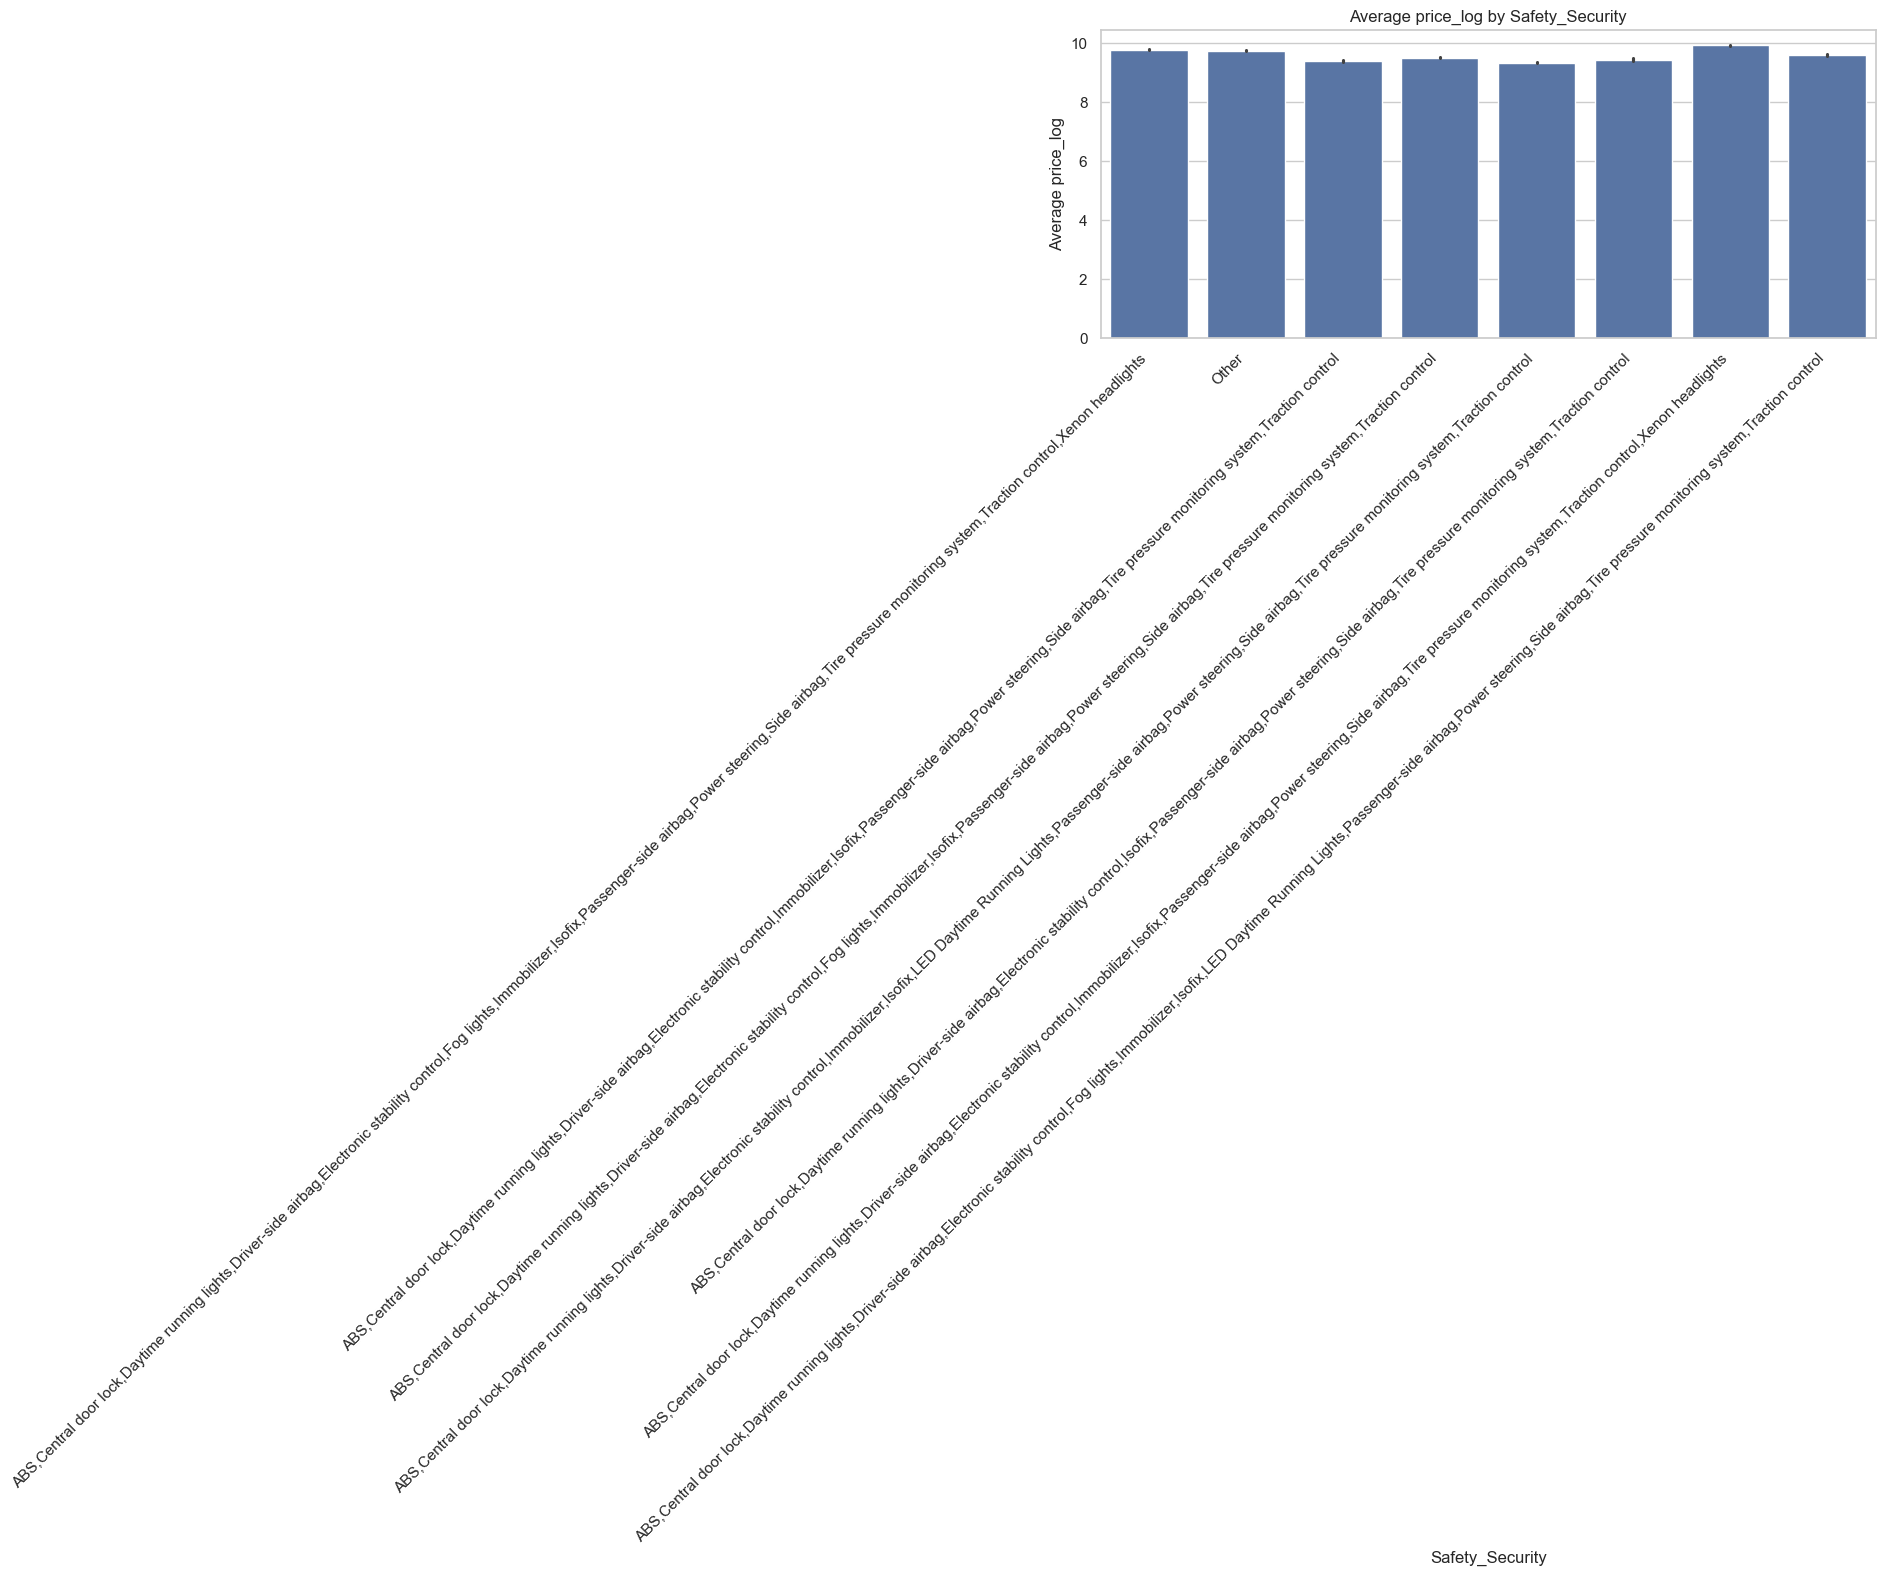

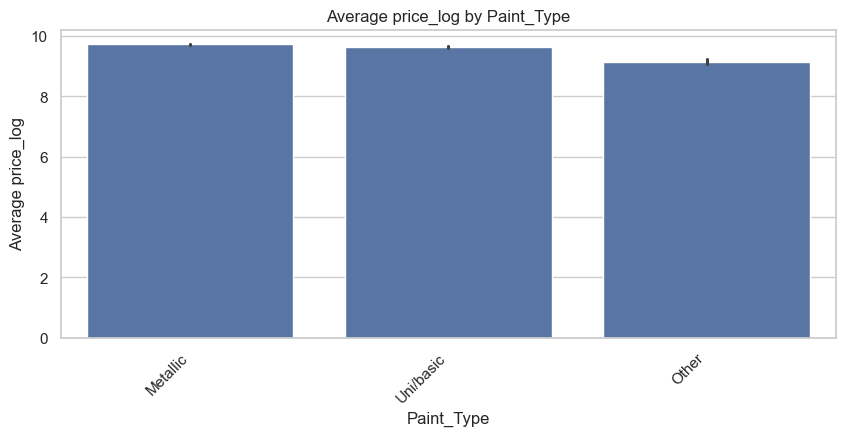

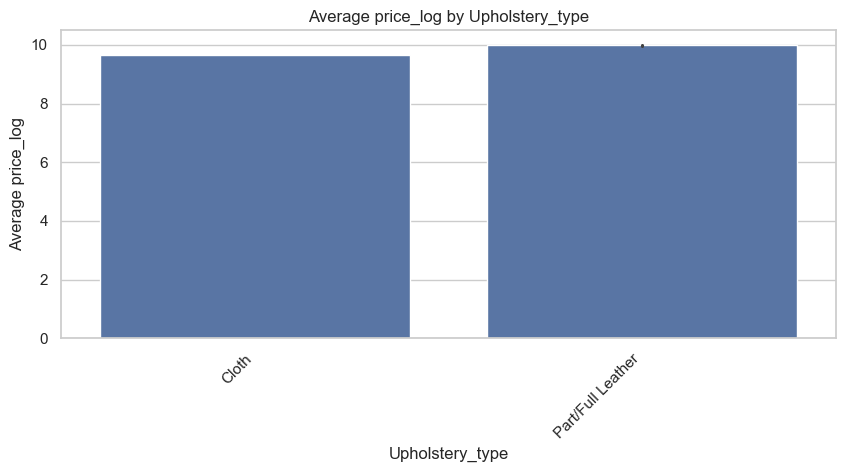

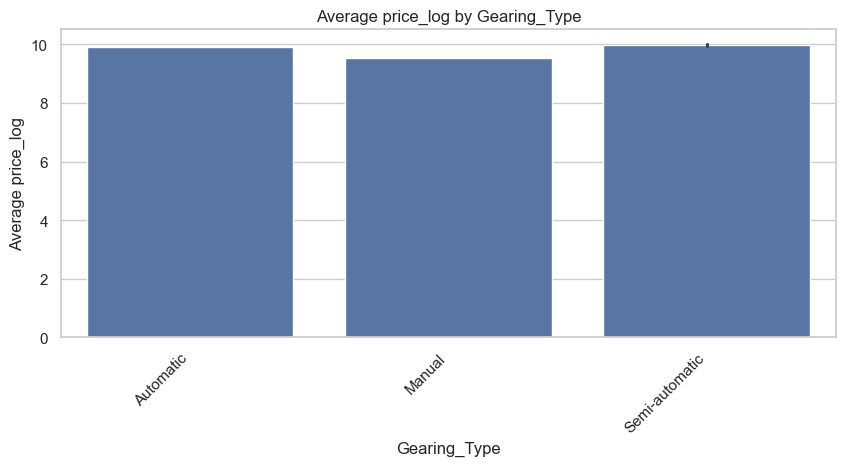

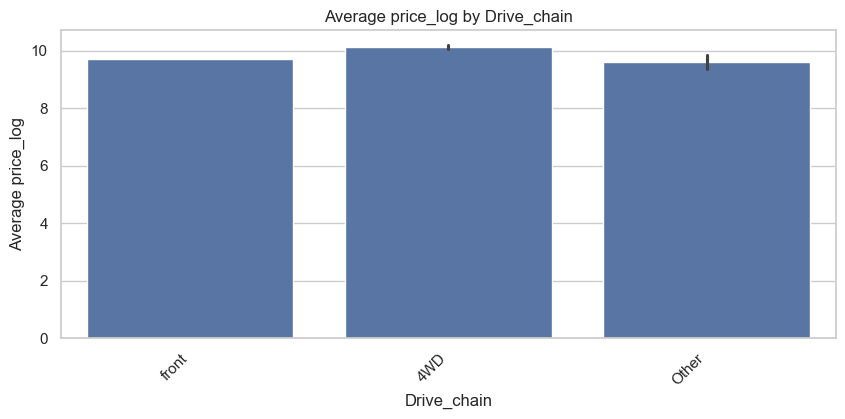

In [36]:
# Comparing average values of target for different categories
import matplotlib.pyplot as plt
import seaborn as sns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_features:
    plt.figure(figsize=(10,4))
    sns.barplot(x=col, y='price_log', data=df, estimator=lambda x: np.mean(x))
    plt.title(f'Average price_log by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Average price_log')
    plt.show()

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

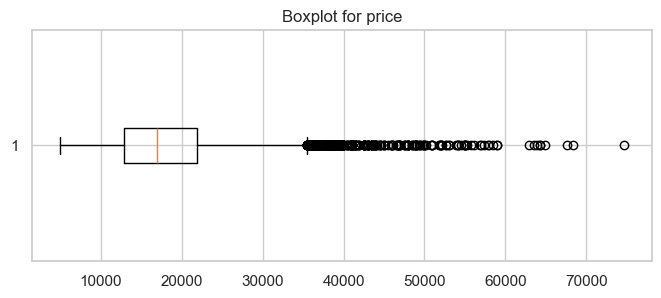

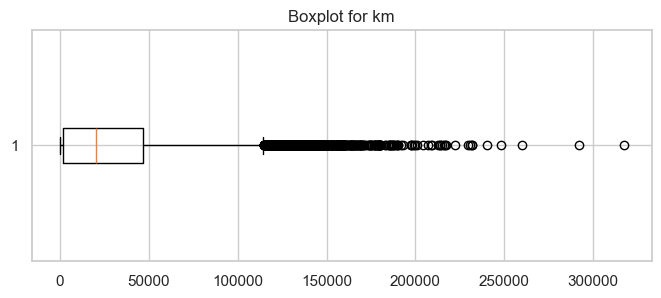

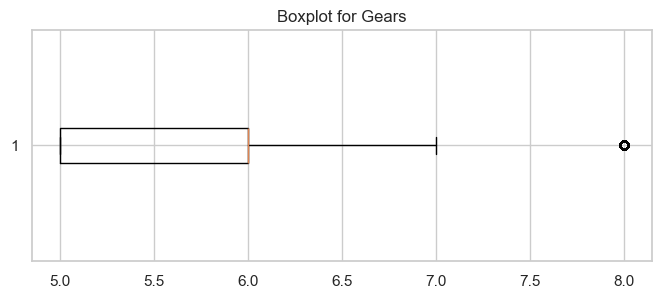

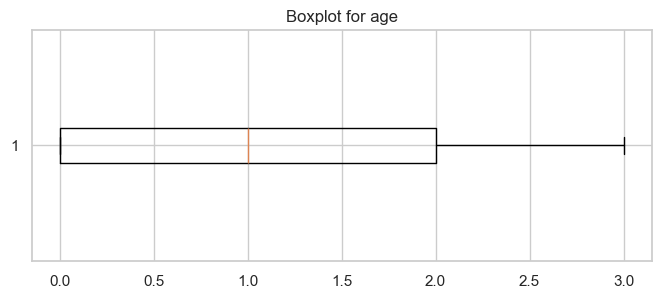

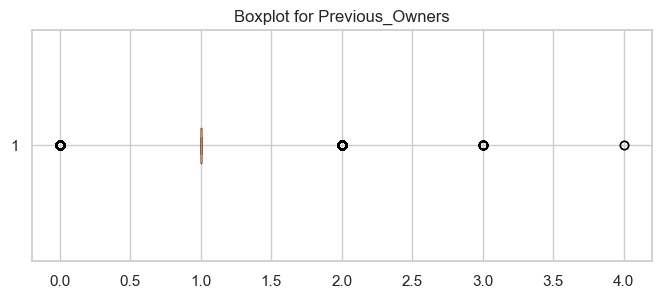

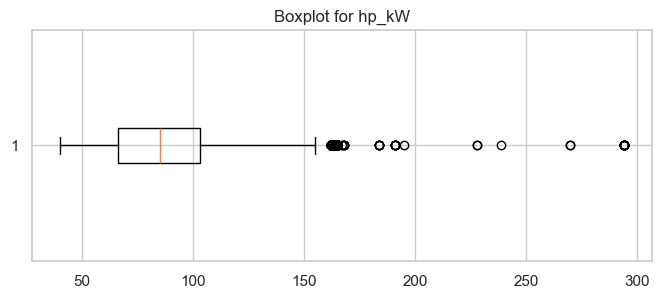

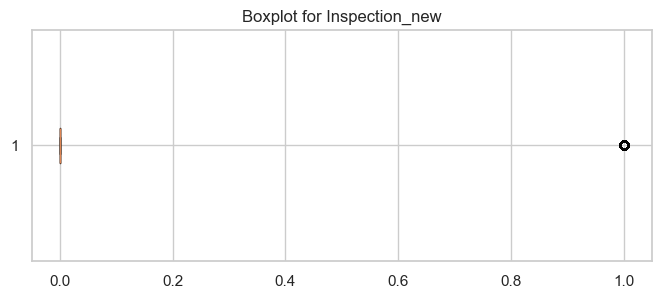

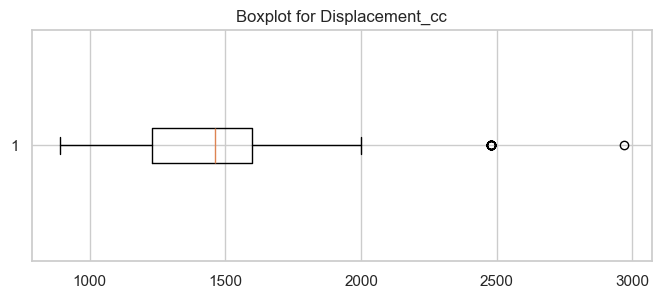

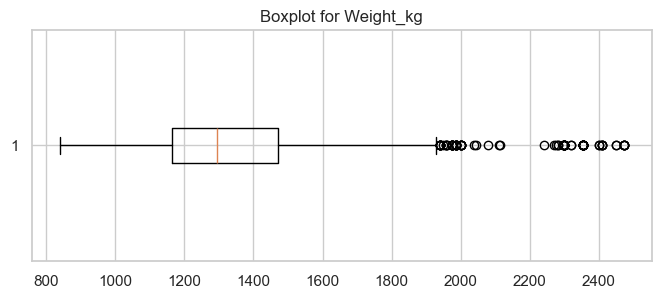

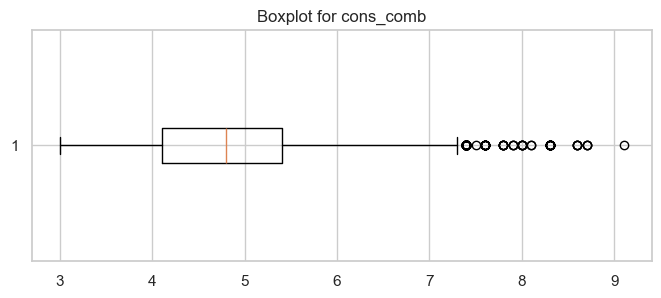

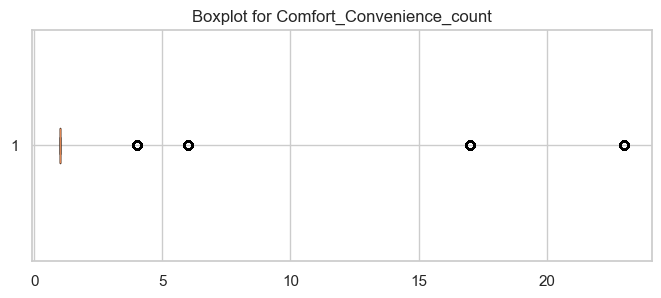

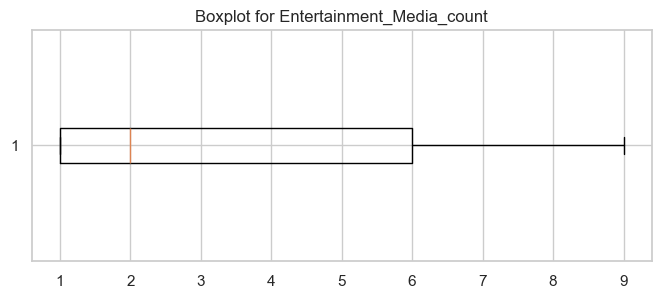

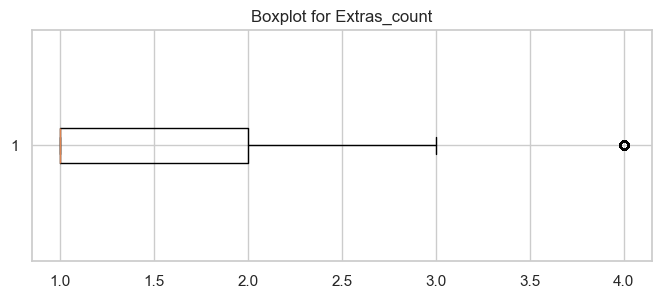

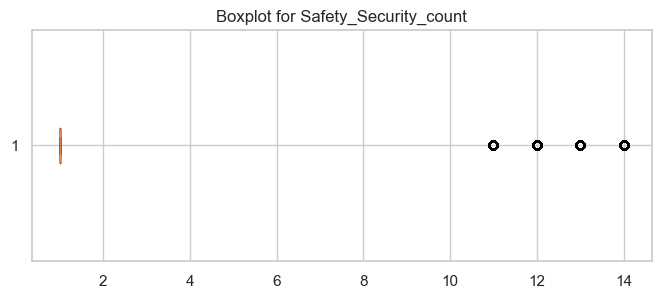

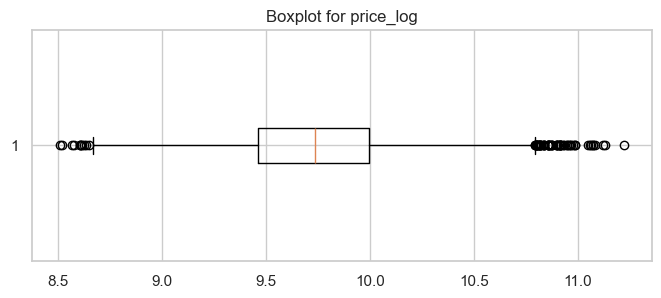

Potential outliers in each numeric column:
price: 479
km: 689
Gears: 225
age: 0
Previous_Owners: 1757
hp_kW: 361
Inspection_new: 3932
Displacement_cc: 21
Weight_kg: 87
cons_comb: 125
Comfort_Convenience_count: 896
Entertainment_Media_count: 0
Extras_count: 192
Safety_Security_count: 2795
price_log: 71


In [37]:
# Outliers present in each column
import matplotlib.pyplot as plt

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_features:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot for {col}')
    plt.show()

outliers_dict = {}
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_dict[col] = outliers.shape[0]

print("Potential outliers in each numeric column:")
for col, count in outliers_dict.items():
    print(f"{col}: {count}")


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [2]:
import pandas as pd

# Load your CSV or Excel file
df = pd.read_csv('Car_Price_data.csv') 

# Now you can handle outliers
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values
    df[col] = df[col].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [3]:
# Fix/create columns as needed
# Drop redundant columns
bundled_cols = ["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]
df = df.drop(columns=bundled_cols)

# Create new features -Age category
df['age_category'] = pd.cut(df['age'], bins=[0,3,7,15,100], labels=['New','Slightly Used','Used','Old'])

# Engine efficiency = hp_kW / Displacement_cc
df['power_per_cc'] = df['hp_kW'] / df['Displacement_cc']

# Vehicle weight to power ratio
df['weight_power_ratio'] = df['Weight_kg'] / df['hp_kW']

#Flag if car has only 1 previous owner
df['single_owner'] = df['Previous_Owners'].apply(lambda x: 1 if x == 1 else 0)

# Verification
df.head()


,make_model,body_type,price,vat,km,Type,Fuel,Gears,age,Previous_Owners,...,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb,age_category,power_per_cc,weight_power_ratio,single_owner
0,Audi A1,Sedans,15770.0,VAT deductible,56013.0,Used,Diesel,7.0,3.0,1.0,...,Cloth,Automatic,1422.0,1220.0,front,3.8,New,0.046414,18.484848,1
1,Audi A1,Sedans,14500.0,Price negotiable,80000.0,Used,Benzine,7.0,2.0,1.0,...,Cloth,Automatic,1798.0,1255.0,front,5.6,New,0.078420,8.900709,1
2,Audi A1,Sedans,14640.0,VAT deductible,83450.0,Used,Diesel,7.0,3.0,1.0,...,Cloth,Automatic,1598.0,1135.0,front,3.8,New,0.053191,13.352941,1
3,Audi A1,Sedans,14500.0,VAT deductible,73000.0,Used,Diesel,6.0,3.0,1.0,...,Cloth,Automatic,1422.0,1195.0,front,3.8,New,0.046414,18.106061,1
4,Audi A1,Sedans,16790.0,VAT deductible,16200.0,Used,Diesel,7.0,3.0,1.0,...,Cloth,Automatic,1422.0,1135.0,front,4.1,New,0.046414,17.196970,1


#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [5]:
import pandas as pd

# Reload the original dataset
df_orig = pd.read_csv('Car_Price_data.csv') 

bundled_cols = ["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]

for col in bundled_cols:
    all_features = df_orig[col].dropna().apply(lambda x: [f.strip() for f in str(x).split(',')])
    unique_features = set([item for sublist in all_features for item in sublist])
    print(f"Unique features in {col} ({len(unique_features)}):\n{unique_features}\n")

Unique features in Comfort_Convenience (38):
{'Heated steering wheel', 'Power windows', 'Automatic climate control', 'Leather seats', 'Electrical side mirrors', 'Electric tailgate', 'Rain sensor', 'Parking assist system camera', 'Cruise control', 'Multi-function steering wheel', 'Tinted windows', 'Massage seats', 'Sunroof', 'Heads-up display', 'Parking assist system sensors rear', 'Parking assist system sensors front', 'Air suspension', 'Seat ventilation', 'Park Distance Control', 'Keyless central door lock', 'Leather steering wheel', 'Split rear seats', 'Panorama roof', 'Armrest', 'Hill Holder', 'Lumbar support', 'Light sensor', 'Air conditioning', 'Start-stop system', 'Seat heating', 'Electrically adjustable seats', 'Electrically heated windshield', 'Wind deflector', 'Parking assist system self-steering', 'Electric Starter', 'Auxiliary heating', 'Windshield', 'Navigation system'}

Unique features in Entertainment_Media (10):
{'Hands-free equipment', 'Digital radio', 'On-board compute

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [7]:
# Drop features from df
# List of all binary feature columns from bundled features
bundled_binary_cols = [col for col in df.columns if any(b in col for b in ['Comfort_', 'Entertainment_', 'Extras_', 'Safety_'])]

# Compute the proportion of cars that have each feature
feature_presence = df[bundled_binary_cols].mean()

# Define thresholds
low_thresh = 0.05
high_thresh = 0.95

# Identify features to drop
features_to_drop = feature_presence[(feature_presence < low_thresh) | (feature_presence > high_thresh)].index.tolist()
print(f"Features to drop (too rare or too common):\n{features_to_drop}")

# Drop these features from the dataframe
df = df.drop(columns=features_to_drop)

# Verification
print("Remaining columns:", df.columns)

Features to drop (too rare or too common):
[]
Remaining columns: Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb', 'age_category', 'power_per_cc',
       'weight_power_ratio', 'single_owner'],
      dtype='object')


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Split by cardinality
low_cardinality = [col for col in categorical_features if df[col].nunique() < 20]
high_cardinality = [col for col in categorical_features if df[col].nunique() >= 20]

# One-hot encode low-cardinality features using pandas
df_encoded = pd.get_dummies(df[low_cardinality], drop_first=True)

# Drop original low-cardinality columns
df = df.drop(columns=low_cardinality)

# Concatenate the one-hot encoded columns
df = pd.concat([df, df_encoded], axis=1)

#encode high-cardinality features
le = LabelEncoder()
for col in high_cardinality:
    df[col] = le.fit_transform(df[col])
    
# 5. Verification
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (15915, 44)


,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb,...,Fuel_Diesel,Fuel_Electric,Fuel_LPG/CNG,Paint_Type_Perl effect,Paint_Type_Uni/basic,Upholstery_type_Part/Full Leather,Gearing_Type_Manual,Gearing_Type_Semi-automatic,Drive_chain_front,Drive_chain_rear
0,15770.0,56013.0,7.0,3.0,1.0,66.0,0.0,1422.0,1220.0,3.8,...,True,False,False,False,False,False,False,False,True,False
1,14500.0,80000.0,7.0,2.0,1.0,141.0,0.0,1798.0,1255.0,5.6,...,False,False,False,False,False,False,False,False,True,False
2,14640.0,83450.0,7.0,3.0,1.0,85.0,0.0,1598.0,1135.0,3.8,...,True,False,False,False,False,False,False,False,True,False
3,14500.0,73000.0,6.0,3.0,1.0,66.0,0.0,1422.0,1195.0,3.8,...,True,False,False,False,False,False,False,False,True,False
4,16790.0,16200.0,7.0,3.0,1.0,66.0,0.0,1422.0,1135.0,4.1,...,True,False,False,False,False,False,False,False,True,False


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [13]:
# Split data
from sklearn.model_selection import train_test_split
import numpy as np
# Check if 'price_log' exists, if not create it
if 'price_log' not in df.columns:
    df['price_log'] = np.log1p(df['price'])  # log(1 + price) to handle zeros safely

#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

df = pd.read_csv("Car_Price_data.csv")

# Create log target if not present
if 'price_log' not in df.columns:
    df['price_log'] = np.log1p(df['price'])

# Split predictors and target
X = df.drop(columns=['price', 'price_log'])
y = df['price_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# numeric columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Scale numeric features
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Output
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (12732, 22)
X_test_scaled shape: (3183, 22)


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [5]:
# Initialise and train model
# Keep only numeric features
X = df.select_dtypes(include=['int64', 'float64'])

# Target
y = df['price_log']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# Evaluate the model's performance
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Evaluation metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("Training R²:", round(r2_train, 2))
print("Testing R²:", round(r2_test, 2))
print("Testing MSE:", round(mse_test, 2))
print("Testing RMSE:", round(rmse_test, 2))


Training R²: 1.0
Testing R²: 1.0
Testing MSE: 0.0
Testing RMSE: 0.0


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

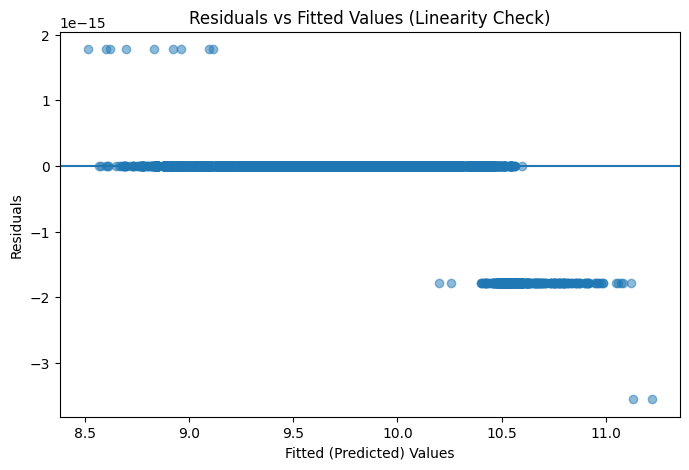

In [7]:
# Linearity check: Plot residuals vs fitted values
import matplotlib.pyplot as plt

# Predictions on training data
y_train_pred = lr_model.predict(X_train_scaled)

# Residuals
residuals = y_train - y_train_pred

# Plot residuals vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Fitted (Predicted) Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Linearity Check)")
plt.show()


Check normality in residual distribution

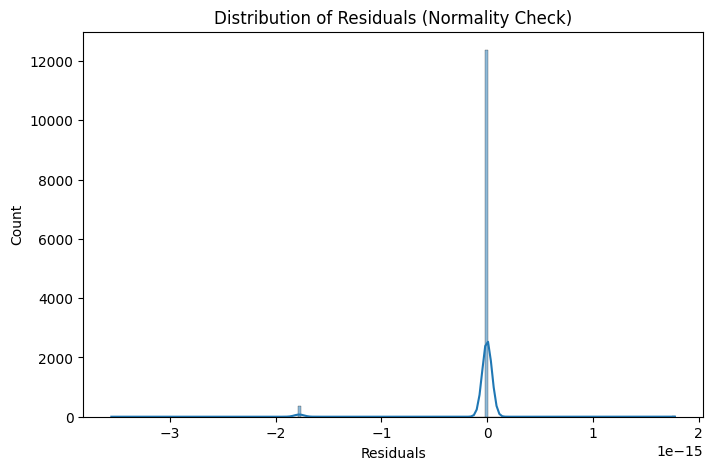

In [8]:
# Check the normality of residuals by plotting their distribution
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals (Normality Check)")
plt.show()


Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [11]:
!pip install statsmodels
import numpy as np
import pandas as pd

# Keep only numeric columns
X_train_num = X_train_scaled.select_dtypes(include=[np.number])
X_test_num = X_test_scaled[X_train_num.columns]
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_num.values, i)
    for i in range(X_train_num.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))
high_vif_features = vif_data[vif_data["VIF"] > 10]["Feature"]

X_train_vif = X_train_num.drop(columns=high_vif_features)
X_test_vif = X_test_num.drop(columns=high_vif_features)

print("Dropped features due to high VIF:", list(high_vif_features))

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 6.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 7.5 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 8.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 8.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 8.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.6 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ---

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [12]:
# List of alphas to tune for Ridge regularisation
import numpy as np

# List of alpha values for Ridge regularization
alphas = np.logspace(-3, 3, 10)

print(alphas)

[1.00000000e-03 4.64158883e-03 2.15443469e-02 1.00000000e-01
 4.64158883e-01 2.15443469e+00 1.00000000e+01 4.64158883e+01
 2.15443469e+02 1.00000000e+03]


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [13]:
# Applying Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

train_scores = []
test_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_vif, y_train)
    
    # Predictions
    y_train_pred = ridge.predict(X_train_vif)
    y_test_pred = ridge.predict(X_test_vif)
    
    # R² scores
    train_scores.append(r2_score(y_train, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))


Best alpha: 46.41588833612773
Best test R²: 0.7994799091306997


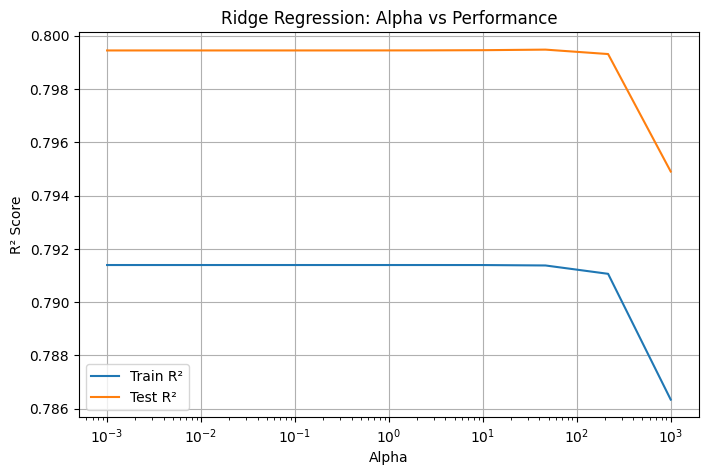

In [14]:
# Plot train and test scores against alpha
best_alpha = alphas[np.argmax(test_scores)]
print("Best alpha:", best_alpha)
print("Best test R²:", max(test_scores))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(alphas, train_scores, label="Train R²")
plt.plot(alphas, test_scores, label="Test R²")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Regression: Alpha vs Performance")
plt.legend()
plt.grid(True)
plt.show()


Find the best alpha value.

In [15]:
# Best alpha value
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
mae_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_vif, y_train)
    
    y_test_pred = ridge.predict(X_test_vif)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    mae_scores.append(mae)

# Best score (negative MAE)
best_alpha = alphas[np.argmin(mae_scores)]
print("Best alpha value:", best_alpha)
best_neg_mae = -min(mae_scores)
print("Best score (negative MAE):", best_neg_mae)


Best alpha value: 0.001
Best score (negative MAE): -0.1440016216467546


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [17]:
# Take a smaller range of alpha to test
fine_alphas = np.linspace(best_alpha*0.9, best_alpha*1.1, 20)

fine_mae_scores = []

for alpha in fine_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_vif, y_train)
    
    y_test_pred = ridge.predict(X_test_vif)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    fine_mae_scores.append(mae)


In [18]:
# Applying Ridge regression
best_fine_alpha = fine_alphas[np.argmin(fine_mae_scores)]
print("Best fine-tuned alpha:", best_fine_alpha)


Best fine-tuned alpha: 0.0009000000000000001


Plot the error-alpha graph again and find the actual optimal value for alpha.

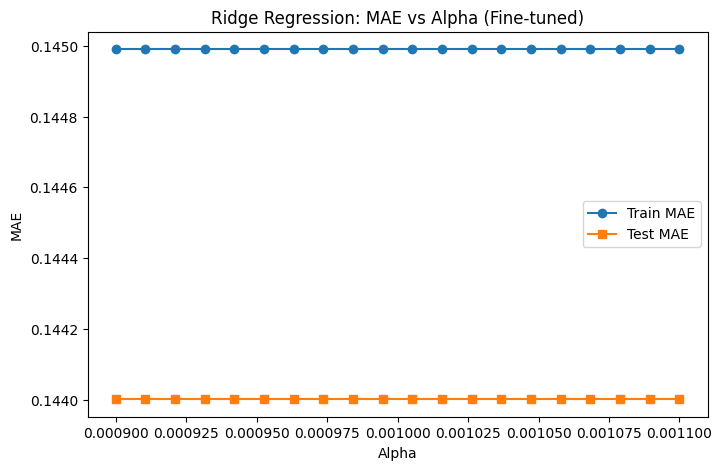

Best alpha value (from fine-tuning): 0.0009000000000000001
Best MAE on test set: 0.14400162153278298


In [19]:
# Plot train and test scores against alpha
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

train_mae_scores = []
test_mae_scores = []

for alpha in fine_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_vif, y_train)
    
    y_train_pred = ridge.predict(X_train_vif)
    y_test_pred = ridge.predict(X_test_vif)
    
    train_mae_scores.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_scores.append(mean_absolute_error(y_test, y_test_pred))

# Plotting
plt.figure(figsize=(8,5))
plt.plot(fine_alphas, train_mae_scores, label='Train MAE', marker='o')
plt.plot(fine_alphas, test_mae_scores, label='Test MAE', marker='s')
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("Ridge Regression: MAE vs Alpha (Fine-tuned)")
plt.legend()
plt.show()

# Best alpha value
best_alpha_final = fine_alphas[np.argmin(test_mae_scores)]
print("Best alpha value (from fine-tuning):", best_alpha_final)

# Best score (negative MAE)
best_mae = min(test_mae_scores)
print("Best MAE on test set:", best_mae)



In [20]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize Ridge with the best alpha from fine-tuning
ridge_best = Ridge(alpha=best_alpha_final)
ridge_best.fit(X_train_vif, y_train)



,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",np.float64(0....0000000000001)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochasti

In [21]:
# Show the coefficients for each feature

# Create a dataframe of feature names and their coefficients
ridge_coeffs = pd.DataFrame({
    'Feature': X_train_vif.columns,
    'Coefficient': ridge_best.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(ridge_coeffs)


           Feature  Coefficient
4            hp_kW     0.236079
1            Gears     0.118420
2              age    -0.104877
0               km    -0.098609
8        cons_comb    -0.077574
6  Displacement_cc    -0.054878
7        Weight_kg     0.053440
5   Inspection_new     0.007586
3  Previous_Owners    -0.002853


In [23]:
# Evaluate the Ridge model on the test data
# Predict on test data
# Evaluate the Ridge model on the test data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test data
y_pred_ridge = ridge_best.predict(X_test_vif)

# Calculate evaluation metrics
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)   # Manually compute RMSE
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Test MAE: {mae_ridge:.4f}")
print(f"Ridge Regression Test MSE: {mse_ridge:.4f}")
print(f"Ridge Regression Test RMSE: {rmse_ridge:.4f}")
print(f"Ridge Regression Test R^2: {r2_ridge:.4f}")




Ridge Regression Test MAE: 0.1440
Ridge Regression Test MSE: 0.0321
Ridge Regression Test RMSE: 0.1790
Ridge Regression Test R^2: 0.7994


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [24]:
# List of alphas to tune for Lasso regularisation
import numpy as np
alphas_lasso = np.logspace(-4, 1, 10)

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [25]:
# Initialise Lasso regression model
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error

train_scores = []
test_scores = []

In [26]:
# Plot train and test scores against alpha
for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_vif, y_train)
    
    # Predict on train and test
    y_train_pred = lasso.predict(X_train_vif)
    y_test_pred = lasso.predict(X_test_vif)
    
    # Store negative MAE (as score)
    train_scores.append(-mean_absolute_error(y_train, y_train_pred))
    test_scores.append(-mean_absolute_error(y_test, y_test_pred))

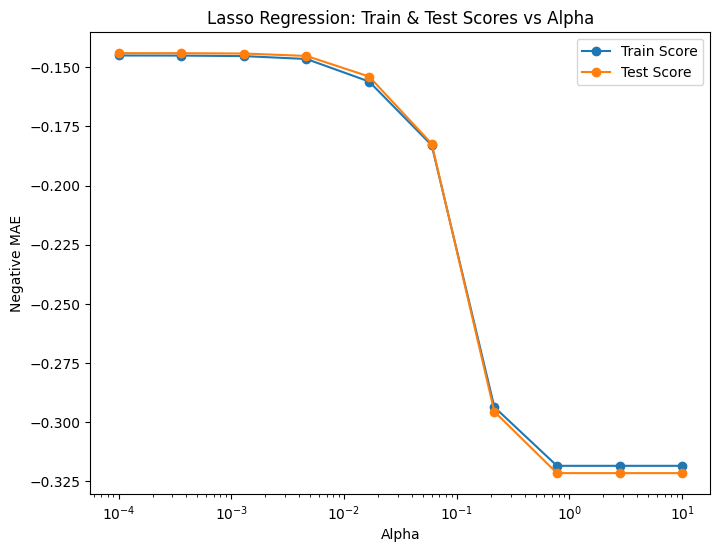

Best alpha: 0.0001
Best negative MAE score: -0.1440


In [27]:
# Best alpha value
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(alphas_lasso, train_scores, label='Train Score', marker='o')
plt.plot(alphas_lasso, test_scores, label='Test Score', marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Negative MAE')
plt.title('Lasso Regression: Train & Test Scores vs Alpha')
plt.legend()
plt.show()

# Best score (negative MAE)
best_idx = np.argmax(test_scores)
best_alpha = alphas_lasso[best_idx]
best_score = test_scores[best_idx]

print(f"Best alpha: {best_alpha}")
print(f"Best negative MAE score: {best_score:.4f}")



#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [28]:
# List of alphas to tune for Lasso regularization
import numpy as np
alphas_fine = np.linspace(best_alpha*0.5, best_alpha*1.5, 10)


In [29]:
# Tuning Lasso hyperparameters
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_scores = []
test_scores = []

for alpha in alphas_fine:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_vif, y_train)
    
    y_train_pred = lasso.predict(X_train_vif)
    y_test_pred = lasso.predict(X_test_vif)
    
    train_scores.append(-mean_absolute_error(y_train, y_train_pred))
    test_scores.append(-mean_absolute_error(y_test, y_test_pred))

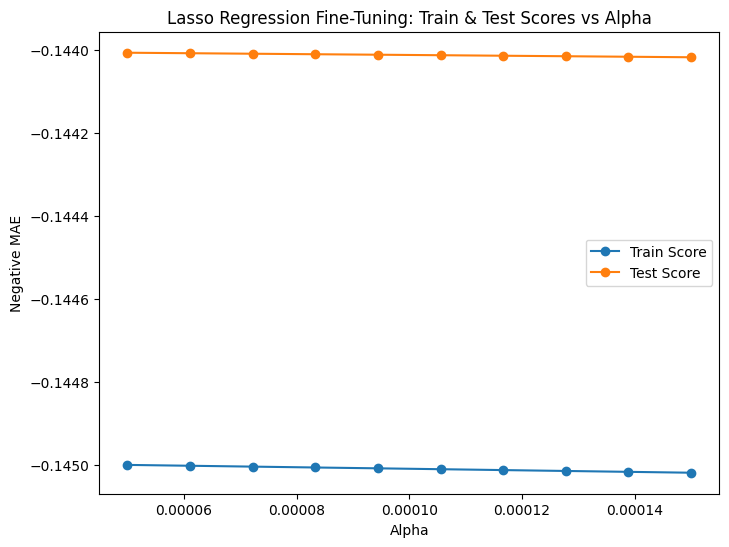

In [30]:
# Plot train and test scores against alpha
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(alphas_fine, train_scores, label='Train Score', marker='o')
plt.plot(alphas_fine, test_scores, label='Test Score', marker='o')
plt.xlabel('Alpha')
plt.ylabel('Negative MAE')
plt.title('Lasso Regression Fine-Tuning: Train & Test Scores vs Alpha')
plt.legend()
plt.show()


In [31]:
# Best alpha value
# Best score (negative MAE)
best_idx_fine = np.argmax(test_scores)
best_alpha_fine = alphas_fine[best_idx_fine]
best_score_fine = test_scores[best_idx_fine]

print(f"Best alpha after fine-tuning: {best_alpha_fine}")
print(f"Best negative MAE score: {best_score_fine:.4f}")



Best alpha after fine-tuning: 5e-05
Best negative MAE score: -0.1440


In [32]:
# Set best alpha for Lasso regression
lasso_best = Lasso(alpha=best_alpha_fine, max_iter=10000)
lasso_best.fit(X_train_vif, y_train)

# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model

lasso_coeffs = pd.Series(lasso_best.coef_, index=X_train_vif.columns)
print("Lasso Coefficients:\n", lasso_coeffs)

Lasso Coefficients:
 km                -0.098581
Gears              0.118409
age               -0.104859
Previous_Owners   -0.002816
hp_kW              0.235928
Inspection_new     0.007525
Displacement_cc   -0.054721
Weight_kg          0.053381
cons_comb         -0.077440
dtype: float64


In [33]:
# Check the coefficients for each feature
y_pred_lasso = lasso_best.predict(X_test_vif)


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate Lasso model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)  # manually compute RMSE
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression Test MAE: {mae_lasso:.4f}")
print(f"Lasso Regression Test MSE: {mse_lasso:.4f}")
print(f"Lasso Regression Test RMSE: {rmse_lasso:.4f}")
print(f"Lasso Regression Test R^2: {r2_lasso:.4f}")


Lasso Regression Test MAE: 0.1440
Lasso Regression Test MSE: 0.0321
Lasso Regression Test RMSE: 0.1790
Lasso Regression Test R^2: 0.7995


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Linear Regression on same features as Ridge/Lasso 
lr_model_vif = LinearRegression()
lr_model_vif.fit(X_train_vif, y_train)

# Predictions 
y_pred_lr = lr_model_vif.predict(X_test_vif)
y_pred_ridge = ridge_best.predict(X_test_vif)
y_pred_lasso = lasso_best.predict(X_test_vif)

# Evaluation
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Metrics:")
    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}\n")
    return mae, mse, rmse, r2

mae_lr, mse_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
mae_ridge, mse_ridge, rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
mae_lasso, mse_lasso, rmse_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

# Comparison DataFrame 
import pandas as pd
metrics_dict = {
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [mae_lr, mae_ridge, mae_lasso],
    "MSE": [mse_lr, mse_ridge, mse_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R^2": [r2_lr, r2_ridge, r2_lasso]
}

metrics_df = pd.DataFrame(metrics_dict)
print(metrics_df)


Linear Regression Metrics:
MAE: 0.1440, MSE: 0.0321, RMSE: 0.1790, R^2: 0.7994

Ridge Regression Metrics:
MAE: 0.1440, MSE: 0.0321, RMSE: 0.1790, R^2: 0.7994

Lasso Regression Metrics:
MAE: 0.1440, MSE: 0.0321, RMSE: 0.1790, R^2: 0.7995

               Model       MAE       MSE      RMSE       R^2
0  Linear Regression  0.144002  0.032056  0.179043  0.799449
1   Ridge Regression  0.144002  0.032056  0.179043  0.799449
2   Lasso Regression  0.144007  0.032055  0.179039  0.799458


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

Features eliminated by Lasso: []


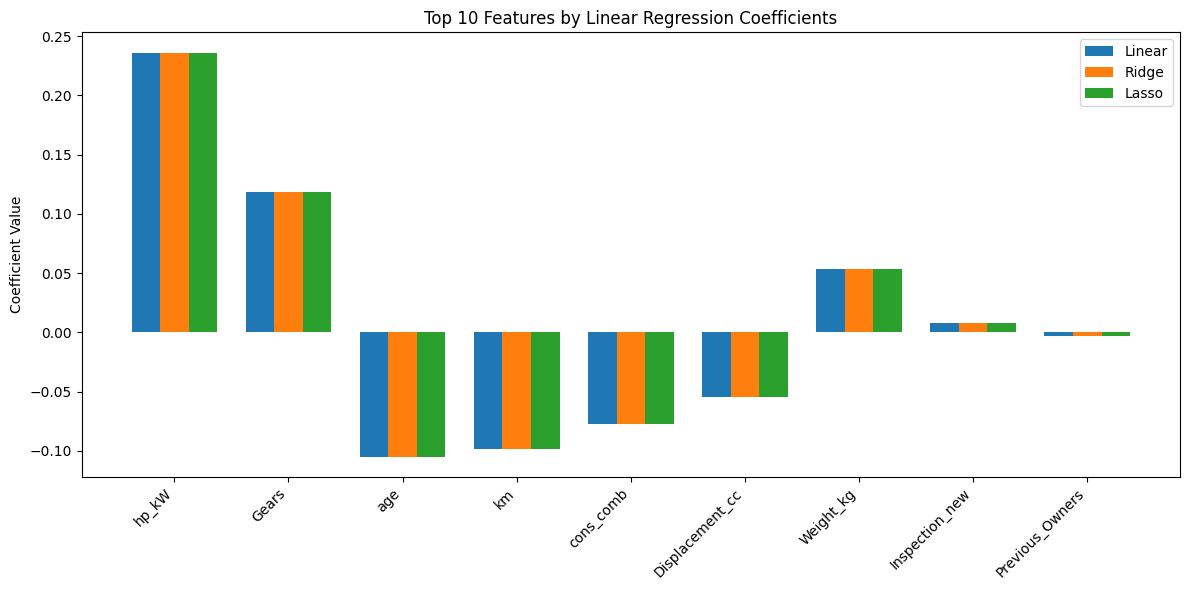

In [45]:
# Compare highest coefficients and coefficients of eliminated features
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Collect coefficients
coeff_df = pd.DataFrame({
    "Feature": X_train_vif.columns,
    "Linear": lr_model_vif.coef_,
    "Ridge": ridge_best.coef_,
    "Lasso": lasso_best.coef_
})

# Identify features eliminated by Lasso 
eliminated_features = coeff_df[coeff_df["Lasso"] == 0]["Feature"].tolist()
print("Features eliminated by Lasso:", eliminated_features)

# Visualise top coefficients
# absolute value to find largest effects
coeff_df["Linear_abs"] = np.abs(coeff_df["Linear"])
coeff_df["Ridge_abs"] = np.abs(coeff_df["Ridge"])
coeff_df["Lasso_abs"] = np.abs(coeff_df["Lasso"])

# Get top 10 features by Linear regression magnitude
top_features = coeff_df.nlargest(10, "Linear_abs")["Feature"]

# Plot coefficients of top features
plt.figure(figsize=(12,6))
width = 0.25
x = np.arange(len(top_features))

plt.bar(x - width, coeff_df.set_index("Feature").loc[top_features, "Linear"], width=width, label="Linear")
plt.bar(x, coeff_df.set_index("Feature").loc[top_features, "Ridge"], width=width, label="Ridge")
plt.bar(x + width, coeff_df.set_index("Feature").loc[top_features, "Lasso"], width=width, label="Lasso")

plt.xticks(x, top_features, rotation=45, ha="right")
plt.ylabel("Coefficient Value")
plt.title("Top 10 Features by Linear Regression Coefficients")
plt.legend()
plt.tight_layout()
plt.show()


## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

In [ ]:
By performing regularization, we observed that Ridge and Lasso regression helped control overfitting by shrinking coefficient values,
with Lasso additionally performing feature selection by eliminating less important features. The overall model performance on the test set
improved slightly compared to baseline Linear Regression, though not drastically, indicating that the original data was reasonably well-behaved.
Some mild overfitting in the baseline model was reduced through regularization, but the dataset size and the presence of categorical features may 
have limited gains. While linear models captured general trends, residual analysis suggested that non-linear relationships might exist, meaning a 
linear model may not fully capture the underlying patterns. Overall, regularization stabilized the model, simplified features, and improved 
generalization, but careful tuning and model choice remain important.

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

In [ ]:
After completing the analysis, we conclude that regularization techniques like Ridge and Lasso are effective in controlling overfitting and 
improving model generalization. Ridge reduced the impact of multicollinearity by shrinking coefficients, while Lasso also performed automatic 
feature selection by eliminating less important predictors. The evaluation metrics showed modest improvements over the baseline Linear Regression, 
indicating that the dataset was fairly clean but still benefited from regularization. We observed that some features had high influence on the target 
variable, and Lasso helped identify them clearly. The insights gained include understanding the importance of scaling, handling multicollinearity,
tuning hyperparameters, and selecting relevant features. Overall, linear models provided a reasonable approximation, but some non-linear patterns may require more advanced models in future analyses.